In [23]:
%load_ext autoreload
%autoreload 2

import asyncio
import aiohttp
import os
import sys
import PIL as pillow
import logging
import orjson

from pathlib import Path
from dotenv import load_dotenv
from datetime import datetime
from IPython.display import HTML

# Load SVG and display with text overlay
from IPython.display import display, SVG
import requests

# Add custom_components to sys.path to allow importing eplucon
root_dir = Path(__file__).resolve().parents[1] if '__file__' in locals() else Path.cwd().parent
custom_components_path = str(root_dir / "custom_components")
if custom_components_path not in sys.path:
    sys.path.append(custom_components_path)

import eplucon.eplucon_api.eplucon_client as eplucon_api_client
from eplucon.const import get_friendly_operation_modes
from eplucon.eplucon_api.DTO import CommonInfoDTO

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



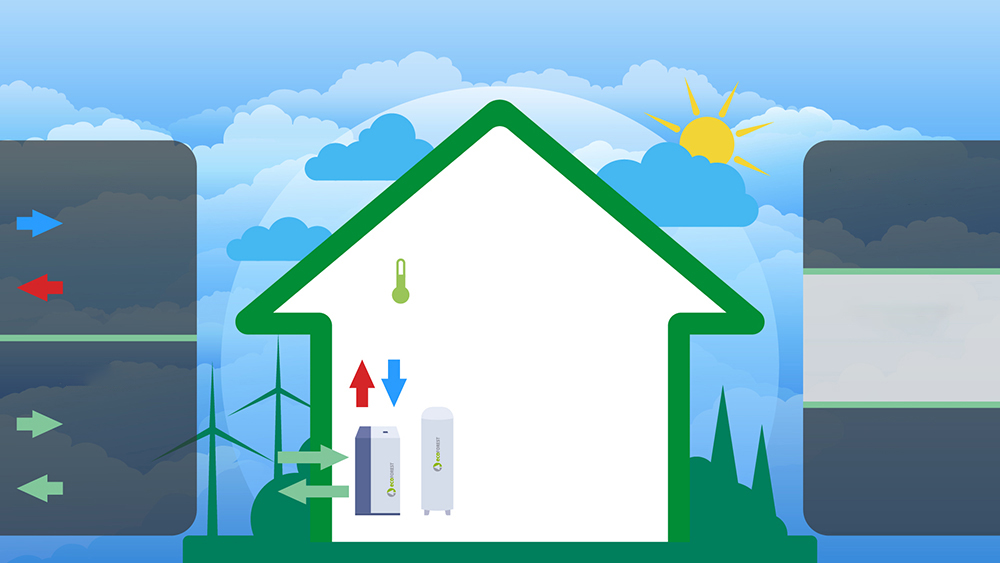

In [142]:
load_dotenv()

API_KEY = os.getenv("API_KEY")

LOGGER = logging.getLogger(__package__)

import base64


def format_temperature(value):
    if value in (None, "", "unknown"):
        return "--"
    return f"{value} °C"


def format_metric(value):
    if value in (None, "", "unknown"):
        return "--"
    return str(value)


async with aiohttp.ClientSession() as session:
    eplucon_api = eplucon_api_client.EpluconApi(API_KEY, None, session)
    devices = await eplucon_api.get_devices()

    for device in devices:
        if device.type != "heat_pump":
            continue

        real_time_data = await eplucon_api.get_realtime_info(device.id)
        json_string = orjson.dumps(
            real_time_data, default=str, option=orjson.OPT_INDENT_2
        ).decode("utf-8")
        # print(json_string)

        operation_mode = real_time_data.common.operation_mode
        operation_mode_text = get_friendly_operation_modes().get(
            operation_mode, "Unknown operation mode"
        )
        indoor_temp = real_time_data.common.indoor_temperature
        outdoor_temp = real_time_data.common.outdoor_temperature
        target_temp = real_time_data.common.configured_indoor_temperature
        ww_temperature = real_time_data.common.ww_temperature
        ww_temperature_configured = real_time_data.common.ww_temperature_configured
        brine_in_temperature = real_time_data.common.brine_in_temperature
        brine_out_temperature = real_time_data.common.brine_out_temperature
        heating_in_temperature = real_time_data.common.heating_in_temperature
        heating_out_temperature = real_time_data.common.heating_out_temperature
        energy_usage = real_time_data.common.energy_usage
        energy_delivered = real_time_data.common.energy_delivered
        spf = real_time_data.common.spf

        screen4_path = root_dir / "custom_components/assets/screen4.svg"
        with open(screen4_path, "r", encoding="utf-8") as file_handle:
            svg_content_heat_pump = file_handle.read()

        prefix_html = ""
        if operation_mode == 1:
            mode_icon_path = root_dir / "custom_components/assets/operation_mode_sun.svg"
            if mode_icon_path.exists():
                with open(mode_icon_path, "r", encoding="utf-8") as file_handle:
                    mode_icon_svg = file_handle.read()
                prefix_html = (
                    '<span style="width: 32px; display: inline-block; '
                    'vertical-align: middle; margin-right: 6px;">'
                    f"{mode_icon_svg}</span>"
                )
        elif operation_mode == 2:
            mode_icon_path = root_dir / "custom_components/assets/operation_mode_snow.svg"
            if mode_icon_path.exists():
                with open(mode_icon_path, "r", encoding="utf-8") as file_handle:
                    mode_icon_svg = file_handle.read()
                prefix_html = (
                    '<span style="width: 32px; display: inline-block; '
                    'vertical-align: middle; margin-right: 6px;">'
                    f"{mode_icon_svg}</span>"
                )

        temperature_icon_html = ""
        temperature_icon_path = root_dir / "custom_components/assets/temperature-high.svg"
        if temperature_icon_path.exists():
            with open(temperature_icon_path, "r", encoding="utf-8") as file_handle:
                temperature_icon_svg = file_handle.read()
            temperature_icon_svg = temperature_icon_svg.replace(
                "<path ", '<path fill="currentColor" ', 1
            )
            temperature_icon_html = (
                '<span style="display: inline-flex; align-items: center; '
                'justify-content: center; width: 42px; height: 42px; '
                'margin-right: 10px; color: #16a34a;">'
                f"{temperature_icon_svg}</span>"
            )

        now = datetime.now()
        datetime_str = now.strftime("%d.%m.%Y %H:%M")

        html_content = f"""
        <div style="position: relative; display: inline-block; width: 800px;">
            <div style="position: absolute; top: 10px; left: 50%; transform: translateX(-50%); font-size: 18px; color: white; z-index: 10; font-family: sans-serif;">
                {datetime_str}
            </div>
            <div style="position: absolute; top: 340px; left: 230px; font-size: 24px; font-variant: small-caps; font-weight: bold; color: black; z-index: 10; font-family: sans-serif; display: flex; align-items: center;">
                {prefix_html}{operation_mode_text.lower()}
            </div>
            <div style="position: absolute; top: 50%; left: 50%; transform: translate(-50%, -50%); font-size: 50px; color: green; font-weight: bold; z-index: 10; font-family: sans-serif; display: flex; align-items: center;">
                {temperature_icon_html}{format_temperature(indoor_temp)}
            </div>
            <div style="width: 800px;">
                {svg_content_heat_pump}
            </div>
        </div>
        """
        display(HTML(html_content))

        screen1_path = root_dir / "custom_components/assets/screen1.jpg"
        with open(screen1_path, "rb") as file_handle:
            screen1_base64 = base64.b64encode(file_handle.read()).decode("ascii")
        screen1_data_uri = f"data:image/jpeg;base64,{screen1_base64}"

        html_content_screen1 = f"""
        <div style="position: relative; display: inline-block; width: 800px; margin-top: 24px;">
            <img src="{screen1_data_uri}" style="display: block; width: 800px; height: auto;" />
            <div style="position: absolute; top: 140px; left: 550px; transform: translateX(-50%); font-size: 20px; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                {format_temperature(outdoor_temp)}
            </div>
            <div style="position: absolute; top: 208px; left: 375px; transform: translate(-50%, -50%); font-size: 16px; color: #16a34a; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(255, 255, 255, 0.35);">
                Actueel
            </div>
            <div style="position: absolute; top: 225px; left: 385px; transform: translate(-50%, -50%); font-size: 24px; color: #16a34a; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(255, 255, 255, 0.35); display: flex; align-items: center; justify-content: center;">
                {format_temperature(indoor_temp)}
            </div>
            <div style="position: absolute; top: 238px; left: 380px; transform: translateX(-50%); font-size: 16px; color: #1f2937; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 2px rgba(255, 255, 255, 0.65);">
                Ingesteld
            </div>
            <div style="position: absolute; top: 255px; left: 385px; transform: translateX(-50%); font-size: 24px; color: #1f2937; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 2px rgba(255, 255, 255, 0.65);">
                {format_temperature(target_temp)}
            </div>
            <div style="position: absolute; top: 328px; left: 475px; transform: translateX(-50%); font-size: 16px; color: #16a34a; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 2px rgba(255, 255, 255, 0.65);">
                Actueel boiler
            </div>
            <div style="position: absolute; top: 345px; left: 490px; transform: translateX(-50%); font-size: 24px; color: #16a34a; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 2px rgba(255, 255, 255, 0.65);">
                {format_temperature(ww_temperature)}
            </div>
            <div style="position: absolute; top: 373px; left: 470px; transform: translateX(-50%); font-size: 16px; color: #1f2937; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 2px rgba(255, 255, 255, 0.65);">
                Ingesteld boiler
            </div>
            <div style="position: absolute; top: 390px; left: 500px; transform: translateX(-50%); font-size: 24px; color: #1f2937; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 2px rgba(255, 255, 255, 0.65);">
                {format_temperature(ww_temperature_configured)}
            </div>
            <div style="position: absolute; top: 133px; left: 70px; transform: translateX(-50%); font-size: 20px; font-variant: small-caps; color: white; z-index: 10; font-family: sans-serif; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                aanvoer
            </div>
            <div style="position: absolute; top: 167px; left: 85px; transform: translateX(-50%); font-size: 20px; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                {format_temperature(heating_in_temperature)}
            </div>
            <div style="position: absolute; top: 219px; left: 85px; transform: translateX(-50%); font-size: 20px; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                {format_temperature(heating_out_temperature)}
            </div>
            <div style="position: absolute; top: 283px; left: 70px; transform: translateX(-50%); font-size: 20px; font-variant: small-caps; color: white; z-index: 10; font-family: sans-serif; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                bron
            </div>
            <div style="position: absolute; top: 327px; left: 90px; transform: translateX(-50%); font-size: 20px; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                {format_temperature(brine_in_temperature)}
            </div>
            <div style="position: absolute; top: 379px; left: 90px; transform: translateX(-50%); font-size: 20px; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                {format_temperature(brine_out_temperature)}
            </div>
            <div style="position: absolute; top: 132px; left: 715px; transform: translateX(-50%); font-size: 15px; font-variant: small-caps; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; letter-spacing: 0.6px; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                opgenomen energie
            </div>
            <div style="position: absolute; top: 172px; left: 715px; transform: translateX(-50%); font-size: 20px; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                {format_metric(energy_usage)} kWh
            </div>
            <div style="position: absolute; top: 235px; left: 715px; transform: translateX(-50%); font-size: 15px; font-variant: small-caps; color: #1f2937; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; letter-spacing: 0.6px; text-shadow: 0 1px 2px rgba(255, 255, 255, 0.65);">
                geleverde energie
            </div>
            <div style="position: absolute; top: 275px; left: 715px; transform: translateX(-50%); font-size: 20px; color: #16a34a; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 2px rgba(255, 255, 255, 0.65);">
                {format_metric(energy_delivered)} kWh
            </div>
            <div style="position: absolute; top: 348px; left: 715px; transform: translateX(-50%); font-size: 15px; font-variant: small-caps; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; letter-spacing: 0.6px; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                spf
            </div>
            <div style="position: absolute; top: 368px; left: 715px; transform: translateX(-50%); font-size: 20px; color: white; z-index: 10; font-family: sans-serif; font-weight: 700; text-align: center; text-shadow: 0 1px 3px rgba(0, 0, 0, 0.55);">
                {format_metric(spf)}
            </div>
        </div>
        """
        display(HTML(html_content_screen1))
        break